In [3]:
# ===== Cell 1: setup & config =====
import os, json, re, collections, math, random
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
import torchvision.transforms as T

# Repro
SEED = 1337
random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- paths (adapt if needed) ----
ROOT = "PartImageNet_Seg/PartImageNet"                 # folder containing 'annotations' and 'images'
TRAIN_ANN = "annotations/train/train.json"
VAL_ANN   = "annotations/val/val.json"
TEST_ANN  = "annotations/test/test.json"

TRAIN_IMG_ROOT = "images/train"
VAL_IMG_ROOT   = "images/val"
TEST_IMG_ROOT  = "images/test"

# ---- AlexNet / ImageNet transforms ----
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.Resize(256),
    T.RandomResizedCrop(224, scale=(0.6, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Minimum crop size in pixels (width/height); use 12+ to skip tiny boxes
MIN_SIZE = 12

print("Device:", DEVICE)


Device: cuda


In [4]:
# ===== Cell 2: dataset helpers (robust key lookup; bbox/seg -> crop; path resolution) =====

FILE_KEYS  = ["file_name","fileName","path","image","name"]
CATID_KEYS = ["category_id","categoryId","object_category_id","obj_cat"]
BBOX_KEYS  = ["bbox","bBox","box"]
SEG_KEYS   = ["segmentation","seg","polygon"]

def _find_any(d, keys):
    for k in keys:
        if k in d: return d[k]
    return None

def _derive_part_from_category_name(cat_name: str) -> str:
    if not cat_name: return "misc"
    s = re.sub(r"[-_]+", " ", str(cat_name).strip().lower())
    toks = s.split()
    return toks[-1] if toks else "misc"   # e.g., 'Biped Body' -> 'body'

def _box_from_poly(poly):
    xs = poly[0::2]; ys = poly[1::2]
    return [float(min(xs)), float(min(ys)), float(max(xs)-min(xs)), float(max(ys)-min(ys))]

def pil_crop_from_ann(img: Image.Image, ann: dict):
    bx = _find_any(ann, BBOX_KEYS)
    if bx is None:
        seg = _find_any(ann, SEG_KEYS)
        if seg and isinstance(seg, list) and len(seg) > 0:
            poly = seg[0] if isinstance(seg[0], list) else seg
            if isinstance(poly, dict) and "counts" in poly:
                # RLE mask not supported here — fallback to full image (skip via size below)
                return None
            bx = _box_from_poly(poly)
        else:
            return None
    if isinstance(bx, dict):
        x,y,w,h = float(bx.get("x",0)), float(bx.get("y",0)), float(bx.get("width",0)), float(bx.get("height",0))
    else:
        x,y,w,h = map(float, bx)
    x0, y0 = int(max(0, x)), int(max(0, y))
    x1, y1 = int(min(img.width, x+w)), int(min(img.height, y+h))
    if x1 <= x0 or y1 <= y0: return None
    return img.crop((x0, y0, x1, y1))

def resolve_path(root: str, images_root: str, fn: str) -> Optional[str]:
    # Try several plausible locations
    base = Path(root)
    imroot = base / images_root if images_root else base
    candidates = [
        imroot / fn,                          # images/train/nXXXX.JPEG
        base / "images" / fn,                 # images/nXXXX.JPEG
        base / "JPEGImages" / fn,             # JPEGImages/nXXXX.JPEG
        base / fn,                            # direct
        base.parent / fn,                     # parent
    ]
    for p in candidates:
        if p.exists(): return str(p)
    return None


In [5]:
# ===== Cell 3: global clusters + dataset definition =====
import collections

def build_global_clusters(root: str, ann_paths: List[str]) -> Dict[str, List[str]]:
    """part_token -> sorted list of ORIGINAL category names (global vocab across splits)."""
    by_part = collections.defaultdict(set)
    for rel in ann_paths:
        p = os.path.join(root, rel)
        if not os.path.exists(p): 
            print("[warn] missing ann:", p)
            continue
        J = json.load(open(p, "r"))
        for c in J.get("categories", []):
            nm = str(c.get("name","")).strip()
            if not nm: continue
            by_part[_derive_part_from_category_name(nm)].add(nm)
    return {part: sorted(names) for part, names in by_part.items()}

GLOBAL_CLUSTERS = build_global_clusters(ROOT, [TRAIN_ANN, VAL_ANN, TEST_ANN])
CANONICAL_PARTS = sorted(GLOBAL_CLUSTERS.keys())
PART_TO_IDX = {p:i for i,p in enumerate(CANONICAL_PARTS)}
print("Discovered parts:", CANONICAL_PARTS)

class PartExample:
    __slots__ = ("img_path","part_canonical","cluster_name","bbox_or_seg_ann","image_id")
    def __init__(self, img_path: str, part_canonical: str, cluster_name: str, bbox_or_seg_ann: dict, image_id: int):
        self.img_path = img_path
        self.part_canonical = part_canonical   # e.g., 'body'
        self.cluster_name = cluster_name       # original category name, e.g., 'Biped Body'
        self.bbox_or_seg_ann = bbox_or_seg_ann
        self.image_id = image_id

class PartCropDataset2(Dataset):
    def __init__(self, root: str, json_path: str, images_root: str,
                 transform=None, min_size: int = 12,
                 global_clusters: Optional[Dict[str, List[str]]] = None):
        super().__init__()
        self.root, self.images_root = root, images_root
        self.transform = transform
        self.min_size = min_size
        self.global_clusters = global_clusters or GLOBAL_CLUSTERS

        J = json.load(open(os.path.join(root, json_path), "r"))
        self.cat_map = {int(c["id"]): c for c in J.get("categories", []) if "id" in c}

        # image_id -> resolved file path
        self.image_map = {}
        for im in J.get("images", []):
            fn = _find_any(im, FILE_KEYS)
            if not fn: continue
            im_id = im.get("id", im.get("image_id", len(self.image_map)))
            full = resolve_path(root, images_root, fn)
            if full: self.image_map[im_id] = full

        # Build items list (skip bad entries)
        items = []
        miss_path = miss_cat = tiny_box = 0
        for a in J.get("annotations", []):
            img_id = a.get("image_id", a.get("id"))
            full = self.image_map.get(img_id)
            if not full or not os.path.exists(full):
                miss_path += 1; 
                continue

            cid = _find_any(a, CATID_KEYS)
            cat = self.cat_map.get(int(cid), {}) if cid is not None else {}
            cat_name = cat.get("name"); supercat = cat.get("supercategory")
            if not cat_name and not supercat:
                miss_cat += 1; 
                continue

            # quickly test crop size to filter tiny/invalid
            try:
                with Image.open(full) as img:
                    img = img.convert("RGB")
                    crop = pil_crop_from_ann(img, a)
            except Exception:
                crop = None
            if crop is None or crop.width < self.min_size or crop.height < self.min_size:
                tiny_box += 1; 
                continue

            part = _derive_part_from_category_name(cat_name or "")
            cluster_name = str(cat_name or supercat or "unknown")
            items.append(PartExample(full, part, cluster_name, a, img_id))

        self.items: List[PartExample] = items

        # Build detector_clusters with the provided global order
        self.detector_clusters: Dict[str, Dict[str,int]] = {
            p: {name:i for i, name in enumerate(self.global_clusters.get(p, []))}
            for p in CANONICAL_PARTS
        }

        # Count OOV (cluster names present in items but not in global map)
        self.oov_counts = {}
        for it in self.items:
            if it.cluster_name not in self.detector_clusters.get(it.part_canonical, {}):
                self.oov_counts[it.part_canonical] = self.oov_counts.get(it.part_canonical, 0) + 1

        print(f"[PartCropDataset2] images={len(self.image_map)} items={len(self.items)} "
              f"miss_path={miss_path} miss_cat={miss_cat} tiny/invalid={tiny_box}")
        if self.oov_counts:
            print("OOV cluster labels found (ignored at __getitem__):", self.oov_counts)

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        it = self.items[idx]
        img = Image.open(it.img_path).convert("RGB")
        crop = pil_crop_from_ann(img, it.bbox_or_seg_ann)
        if crop is None:
            # fallback black chip (should be rare); will be dropped by transform
            crop = Image.new("RGB", (224,224), (0,0,0))
        x = self.transform(crop) if self.transform else T.ToTensor()(crop)
        det_idx = PART_TO_IDX.get(it.part_canonical, -1)             # which detector (canonical part)
        # cluster index within canonical part (may be -1 if OOV)
        cluster_idx = self.detector_clusters.get(it.part_canonical, {}).get(it.cluster_name, -1)
        return x, det_idx, cluster_idx, it.image_id


Discovered parts: ['body', 'engine', 'fin', 'foot', 'hand', 'head', 'mirror', 'mouth', 'sail', 'seat', 'tail', 'tier', 'wing']


In [6]:
# ===== Cell 4: instantiate datasets =====
ds_tr = PartCropDataset2(ROOT, TRAIN_ANN, TRAIN_IMG_ROOT, transform=train_tf, min_size=MIN_SIZE, global_clusters=GLOBAL_CLUSTERS)
ds_val = PartCropDataset2(ROOT, VAL_ANN,   VAL_IMG_ROOT,   transform=eval_tf,   min_size=MIN_SIZE, global_clusters=GLOBAL_CLUSTERS)

print("num part-crops (train):", len(ds_tr))
print("num part-crops (val):  ", len(ds_val))
print("parts:", CANONICAL_PARTS)
for p in CANONICAL_PARTS:
    print(f"{p:12s} -> {len(ds_tr.detector_clusters[p])} clusters in train")


[PartCropDataset2] images=20466 items=90849 miss_path=0 miss_cat=0 tiny/invalid=4210
[PartCropDataset2] images=1206 items=5334 miss_path=0 miss_cat=0 tiny/invalid=292
num part-crops (train): 90849
num part-crops (val):   5334
parts: ['body', 'engine', 'fin', 'foot', 'hand', 'head', 'mirror', 'mouth', 'sail', 'seat', 'tail', 'tier', 'wing']
body         -> 11 clusters in train
engine       -> 1 clusters in train
fin          -> 1 clusters in train
foot         -> 4 clusters in train
hand         -> 1 clusters in train
head         -> 8 clusters in train
mirror       -> 1 clusters in train
mouth        -> 1 clusters in train
sail         -> 1 clusters in train
seat         -> 1 clusters in train
tail         -> 6 clusters in train
tier         -> 2 clusters in train
wing         -> 2 clusters in train


In [7]:
# ===== Cell 5: binary (pos/neg) view per part =====
class BinaryPartDataset(Dataset):
    """Wraps PartCropDataset2 -> returns (x, y_binary, image_id) for a single canonical part.
       y_binary: 1 if item.part_canonical == target_part else 0.
       Optionally downsample negatives to keep neg:pos ~ max_neg_per_pos.
    """
    def __init__(self, base: PartCropDataset2, target_part: str, transform=None, max_neg_per_pos: float = 3.0):
        self.base = base
        self.part = target_part
        self.transform = transform or base.transform
        self.pos_ids = [i for i, it in enumerate(base.items) if it.part_canonical == target_part]
        self.neg_ids = [i for i, it in enumerate(base.items) if it.part_canonical != target_part]
        if max_neg_per_pos is not None and math.isfinite(max_neg_per_pos):
            # simple downsample to keep manageable class balance
            max_neg = int(max_neg_per_pos * max(1, len(self.pos_ids)))
            if len(self.neg_ids) > max_neg:
                random.shuffle(self.neg_ids)
                self.neg_ids = self.neg_ids[:max_neg]
        self.ids = self.pos_ids + self.neg_ids
        self.labels = [1]*len(self.pos_ids) + [0]*len(self.neg_ids)
        print(f"[BinaryPartDataset] part={target_part}  pos={len(self.pos_ids)} neg={len(self.neg_ids)} "
              f"(ratio={len(self.neg_ids)/max(1,len(self.pos_ids)):.2f})")

    def __len__(self): return len(self.ids)

    def __getitem__(self, i):
        j = self.ids[i]; y = self.labels[i]
        x, _, _, imid = self.base[j]
        # ensure identical transform
        if self.transform and x.ndim == 3 and x.shape[-1] in (3,):
            # already transformed by base; nothing extra
            pass
        return x, int(y), imid

def make_balanced_loader(ds: BinaryPartDataset, batch_size: int = 128, num_workers: int = 8, pin_memory: bool = True):
    # Build per-item weights to balance classes inside the dataset
    counts = collections.Counter(ds.labels)
    w = {c: 1.0/max(1, n) for c, n in counts.items()}
    weights = torch.tensor([w[int(y)] for y in ds.labels], dtype=torch.float)
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
    return DataLoader(ds, batch_size=batch_size, sampler=sampler, num_workers=num_workers, pin_memory=pin_memory, drop_last=False)


In [8]:
# ===== Cell 6: binary ResNet model + training loop =====
import os
from pathlib import Path
from typing import Optional, List

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader

# Make sure we can import the helper module
import sys
p_candidates = [Path('.'), Path('/mnt/data')]
for pth in p_candidates:
    if str(pth.resolve()) not in sys.path:
        sys.path.append(str(pth.resolve()))

try:
    from part_detector_refactor import PartDetectorTiny
except Exception as e:
    # Robust fallback: load directly from a file path if present
    mod_path = Path('part_detector_refactor.py')
    if mod_path.exists():
        import importlib.util
        spec = importlib.util.spec_from_file_location('part_detector_refactor', str(mod_path))
        m = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(m)  # type: ignore
        PartDetectorTiny = m.PartDetectorTiny  # type: ignore
    else:
        raise e

class BinaryResNet(nn.Module):
    """Two-way (pos/neg) classifier using a ResNet backbone via PartDetectorTiny."""
    def __init__(self, emb_dim: int = 128, variant: str = 'resnet50', 
                 backbone_trainable: bool = True, weights: Optional[str] = 'imagenet'):
        super().__init__()
        self.net = PartDetectorTiny(
            emb_dim=emb_dim, num_classes=2,
            backbone=variant, backbone_trainable=backbone_trainable, weights=weights
        )
    def forward(self, x):
        _, logits = self.net(x)
        return logits

@torch.no_grad()
def binary_acc(logits: torch.Tensor, y: torch.Tensor) -> float:
    return (logits.argmax(1) == y).float().mean().item()

def train_binary_for_part_resnet(part_name: str,
                                 ds_train: 'PartCropDataset2',
                                 ds_val: Optional['PartCropDataset2'],
                                 outdir: str = 'resnet_binary_ckpts',
                                 epochs: int = 20,
                                 batch_size: int = 128,
                                 lr: float = 3e-4,
                                 emb_dim: int = 128,
                                 max_neg_per_pos: float = 3.0,
                                 use_amp: bool = True,
                                 channels_last: bool = True,
                                 use_tf32: bool = True,
                                 num_workers: int = 8,
                                 # ResNet-specific options
                                 variant: str = 'resnet50',
                                 backbone_trainable: bool = True,
                                 weights: Optional[str] = 'imagenet'):
    """Mirror the AlexNet binary training loop, swapping in a ResNet backbone."""
    os.makedirs(outdir, exist_ok=True)

    # Datasets / loaders (reuse BinaryPartDataset & make_balanced_loader from Cell 5)
    tr_bin = BinaryPartDataset(ds_train, part_name, transform=ds_train.transform, max_neg_per_pos=max_neg_per_pos)
    vl_bin = BinaryPartDataset(ds_val,   part_name, transform=(ds_val.transform if ds_val else None), 
                               max_neg_per_pos=max_neg_per_pos) if ds_val is not None else None

    dl_tr = make_balanced_loader(tr_bin, batch_size=batch_size, num_workers=num_workers, pin_memory=(DEVICE.type=='cuda'))
    dl_vl = DataLoader(vl_bin, batch_size=batch_size, shuffle=False, num_workers=num_workers, 
                       pin_memory=(DEVICE.type=='cuda')) if vl_bin else None

    # Model
    torch.backends.cuda.matmul.allow_tf32 = bool(use_tf32)
    model = BinaryResNet(emb_dim=emb_dim, variant=variant, backbone_trainable=backbone_trainable, weights=weights).to(DEVICE)
    if channels_last and DEVICE.type == 'cuda':
        try: model = model.to(memory_format=torch.channels_last)
        except Exception: pass

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2)
    scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and DEVICE.type=='cuda'))
    best_va = -1.0; best_path = None

    for ep in range(1, epochs+1):
        # ---- train ----
        model.train()
        tr_loss = 0.0; tr_acc = 0.0; nbt = 0
        for xb, yb, _ in dl_tr:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True).long()
            if channels_last and xb.ndim == 4 and DEVICE.type=='cuda':
                try: xb = xb.to(memory_format=torch.channels_last)
                except Exception: pass
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):
                logits = model(xb)
                loss = F.cross_entropy(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            tr_loss += float(loss.item()); tr_acc += binary_acc(logits, yb); nbt += 1
        tr_loss /= max(1, nbt); tr_acc /= max(1, nbt)

        # ---- val ----
        va_loss = va_acc = 0.0; nvb = 0
        if dl_vl is not None:
            model.eval()
            with torch.no_grad():
                for xb, yb, _ in dl_vl:
                    xb = xb.to(DEVICE, non_blocking=True)
                    yb = yb.to(DEVICE, non_blocking=True).long()
                    if channels_last and xb.ndim == 4 and DEVICE.type=='cuda':
                        try: xb = xb.to(memory_format=torch.channels_last)
                        except Exception: pass
                    logits = model(xb)
                    loss = F.cross_entropy(logits, yb)
                    va_loss += float(loss.item()); va_acc += binary_acc(logits, yb); nvb += 1
            va_loss /= max(1, nvb); va_acc /= max(1, nvb)
            sch.step(va_loss)

        print(f"[{part_name}] ep {ep:02d}/{epochs}  tr_loss={tr_loss:.4f} tr_acc={tr_acc:.3f}  "
              f"val_loss={va_loss:.4f} val_acc={va_acc:.3f}  lr={opt.param_groups[0]['lr']:.2e}")

        if va_acc > best_va:
            best_va = va_acc
            best_path = os.path.join(outdir, f"{part_name}_resnet_best.pt")
            torch.save({"part": part_name, "state_dict": model.state_dict(), 
                        "emb_dim": emb_dim, "variant": variant}, best_path)

    print(f"[{part_name}] best val_acc={best_va:.3f}  ckpt={best_path}")
    return best_path, best_va


In [9]:
# ===== Cell 7: train all parts (ResNet) =====
from typing import Optional, List, Dict

def train_all_binary_parts_resnet(ds_train: 'PartCropDataset2', ds_val: 'PartCropDataset2',
                                  parts: Optional[List[str]] = None,
                                  **kwargs) -> Dict[str, dict]:
    parts = parts or CANONICAL_PARTS
    results = {}
    for p in parts:
        # check if we have positives in train/val
        n_pos_tr = sum(1 for it in ds_train.items if it.part_canonical == p)
        n_pos_vl = sum(1 for it in ds_val.items   if it.part_canonical == p)
        if n_pos_tr == 0:
            print(f"[skip] part={p}: no positives in train"); continue
        if n_pos_vl == 0:
            print(f"[warn] part={p}: no positives in val; will still train & report train metrics only")
        print("-"*80)
        print(f"Training binary ResNet detector for part: {p}  (train_pos={n_pos_tr}  val_pos={n_pos_vl})")
        ckpt, acc = train_binary_for_part_resnet(p, ds_train, ds_val, **kwargs)
        results[p] = {"ckpt": ckpt, "best_val_acc": float(acc)}
    return results

# Example usage (uncomment to run):
resnet_results = train_all_binary_parts_resnet(
    ds_tr, ds_val,
    epochs=40, batch_size=128, lr=3e-4, emb_dim=128,
    max_neg_per_pos=3.0,
    variant='resnet50', backbone_trainable=True, weights='None'
)
print(resnet_results)


--------------------------------------------------------------------------------
Training binary ResNet detector for part: body  (train_pos=23903  val_pos=1439)
[BinaryPartDataset] part=body  pos=23903 neg=66946 (ratio=2.80)
[BinaryPartDataset] part=body  pos=1439 neg=3895 (ratio=2.71)


/tmp/ipykernel_7792/3290214588.py:85: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and DEVICE.type=='cuda'))
/tmp/ipykernel_7792/3290214588.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


[body] ep 01/40  tr_loss=0.4005 tr_acc=0.814  val_loss=0.3817 val_acc=0.838  lr=3.00e-04
[body] ep 02/40  tr_loss=0.3264 tr_acc=0.854  val_loss=0.3576 val_acc=0.849  lr=3.00e-04
[body] ep 03/40  tr_loss=0.2911 tr_acc=0.871  val_loss=0.3771 val_acc=0.831  lr=3.00e-04
[body] ep 04/40  tr_loss=0.2620 tr_acc=0.888  val_loss=0.3870 val_acc=0.835  lr=3.00e-04
[body] ep 05/40  tr_loss=0.2375 tr_acc=0.898  val_loss=0.3693 val_acc=0.843  lr=1.50e-04
[body] ep 06/40  tr_loss=0.1693 tr_acc=0.932  val_loss=0.3737 val_acc=0.858  lr=1.50e-04
[body] ep 07/40  tr_loss=0.1433 tr_acc=0.943  val_loss=0.3903 val_acc=0.858  lr=1.50e-04
[body] ep 08/40  tr_loss=0.1210 tr_acc=0.953  val_loss=0.4287 val_acc=0.852  lr=7.50e-05
[body] ep 09/40  tr_loss=0.0868 tr_acc=0.968  val_loss=0.4397 val_acc=0.862  lr=7.50e-05
[body] ep 10/40  tr_loss=0.0684 tr_acc=0.975  val_loss=0.4568 val_acc=0.868  lr=7.50e-05
[body] ep 11/40  tr_loss=0.0588 tr_acc=0.979  val_loss=0.4943 val_acc=0.863  lr=3.75e-05
[body] ep 12/40  tr_l

In [1]:
# ===== Cell AR1: load all per-part binary ResNet detectors =====
import os, json, math, random
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import torch, torch.nn as nn, torch.nn.functional as F

from part_detector_refactor import PartDetectorTiny  # ResNet backbones supported

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_DIR_RESNET = "resnet_binary_ckpts"   # folder containing {part}_best.pt from the ResNet training block

class BinaryResNet(nn.Module):
    # 2-way (pos/neg) classifier wrapper with access to (embeddings, logits)
    def __init__(self, emb_dim: int = 128, variant: str = "resnet50"):
        super().__init__()
        self.variant = variant
        self.net = PartDetectorTiny(emb_dim=emb_dim, num_classes=2, backbone=variant, backbone_trainable=True, weights=None)
    def forward(self, x):
        _, logits = self.net(x)
        return logits
    # convenience for tokenization
    def forward_with_emb(self, x):
        return self.net(x)  # -> (emb, logits)

def _load_resnet_detector(path: str) -> Tuple[str, BinaryResNet, int]:
    ck = torch.load(path, map_location=DEVICE)
    part_name = ck.get("part", Path(path).stem.split("_best")[0])
    emb_dim = int(ck.get("emb_dim", 128))
    variant = str(ck.get("variant", "resnet50"))
    m = BinaryResNet(emb_dim=emb_dim, variant=variant)
    m.load_state_dict(ck["state_dict"], strict=True)
    m.to(DEVICE).eval()
    return part_name, m, emb_dim

# Build detectors dict
detectors_resnet: Dict[str, BinaryResNet] = {}
emb_dims = set()
for p in sorted(Path(CKPT_DIR_RESNET).glob("*_best.pt")):
    part_name, model, emb_dim = _load_resnet_detector(str(p))
    detectors_resnet[part_name] = model
    emb_dims.add(emb_dim)
PARTS_ORDER = sorted(detectors_resnet.keys())
print(f"Loaded {len(detectors_resnet)} ResNet detectors:", ", ".join(PARTS_ORDER))

# Use eval transform from Cell 1 if available; else Imagenet eval
import torchvision.transforms as T
VAL_TF = globals().get('eval_tf', T.Compose([
    T.Resize(256), T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
]))


Loaded 13 ResNet detectors: body, engine, fin, foot, hand, head, mirror, mouth, sail, seat, tail, tier, wing


In [9]:
# ===== Cell AR2: object (supercategory) label space + per-image index =====
import json
from collections import defaultdict, Counter

def _name_to_super_from_jsons(paths):
    mp = {}
    for rel in paths:
        jp = os.path.join(ROOT, rel)
        if not os.path.exists(jp): 
            continue
        with open(jp, "r") as f:
            J = json.load(f)
        for c in J.get("categories", []):
            nm = str(c.get("name","")).strip()
            sp = str(c.get("supercategory","Unknown")).strip()
            if nm:
                mp[nm] = sp
    return mp

NAME_TO_SUPER = _name_to_super_from_jsons([TRAIN_ANN, VAL_ANN, TEST_ANN])

def build_image_index(ds: 'PartCropDataset2'):
    """Return:
       - img_to_idxs: {image_id: [dataset indices belonging to that image]}
       - img_to_super: {image_id: supercategory string}, skipping ambiguous images
    """
    img_to_idxs = defaultdict(list)
    for i, it in enumerate(ds.items):
        img_to_idxs[it.image_id].append(i)
    # per-image supercategory from original category names
    img_to_super = {}
    for iid, idxs in img_to_idxs.items():
        sups = []
        for j in idxs:
            nm = ds.items[j].cluster_name  # original category name
            sup = NAME_TO_SUPER.get(nm, None)
            if sup: sups.append(sup)
        if len(sups) == 0:
            continue
        most = Counter(sups).most_common()
        # keep only if unambiguous majority
        if len(set(sups)) == 1 or (len(most) >= 1 and (len(most) == 1 or most[0][1] > most[1][1])):
            img_to_super[iid] = most[0][0]
    return img_to_idxs, img_to_super

# Reuse datasets (built in Cell 4); build if missing
if 'ds_tr' not in globals():
    ds_tr = PartCropDataset2(ROOT, TRAIN_ANN, TRAIN_IMG_ROOT, transform=eval_tf, min_size=MIN_SIZE, global_clusters=GLOBAL_CLUSTERS)
if 'ds_val' not in globals():
    ds_val = PartCropDataset2(ROOT, VAL_ANN,   VAL_IMG_ROOT,   transform=eval_tf,   min_size=MIN_SIZE, global_clusters=GLOBAL_CLUSTERS)

tr_img2idxs, tr_img2super = build_image_index(ds_tr)
vl_img2idxs, vl_img2super = build_image_index(ds_val)

OBJECT_CLASSES = sorted(set(tr_img2super.values()) | set(vl_img2super.values()))
OBJ_TO_IDX = {n:i for i,n in enumerate(OBJECT_CLASSES)}
print("Object classes:", OBJECT_CLASSES)


Object classes: ['Aeroplane', 'Bicycle', 'Biped', 'Bird', 'Boat', 'Bottle', 'Car', 'Fish', 'Quadruped', 'Reptile', 'Snake']


In [10]:
# ===== Cell AR3: tokenization — per-image sequence of part tokens (ResNet detectors) =====
import numpy as np
from typing import Optional, List, Tuple
from PIL import Image

@torch.no_grad()
def _tokens_for_image(ds: 'PartCropDataset2',
                      img_indices: List[int],
                      detectors: Dict[str, BinaryResNet],
                      parts_order: List[str],
                      device=DEVICE) -> Tuple[torch.Tensor, torch.Tensor]:
    """Return:
      emb_tokens:   [K, E]  (per-part aggregated embedding, weighted by p(pos))
      score_tokens: [K, 1]  (per-part scalar score s_p = max_i p(pos))
    K = len(parts_order).
    """
    chips_by_part = {p: [] for p in parts_order}
    for j in img_indices:
        it = ds.items[j]
        p = it.part_canonical
        if p not in detectors:
            continue
        try:
            with Image.open(it.img_path) as img:
                img = img.convert("RGB")
                crop = pil_crop_from_ann(img, it.bbox_or_seg_ann)
        except Exception:
            crop = None
        if crop is None:
            continue
        x = VAL_TF(crop) if VAL_TF is not None else T.ToTensor()(crop)
        chips_by_part[p].append(x)

    emb_tokens, score_tokens = [], []
    for p in parts_order:
        xs = chips_by_part[p]
        if len(xs) == 0:
            model = detectors[p]
            try:
                dummy = torch.zeros(1,3,224,224, device=device)
                z, lg = model.forward_with_emb(dummy)
                E = z.shape[1]
            except Exception:
                E = 128
            emb_tokens.append(torch.zeros(E))
            score_tokens.append(torch.zeros(1))
            continue
        xb = torch.stack(xs, 0).to(device, non_blocking=True)
        z, logits = detectors[p].forward_with_emb(xb)
        probs = F.softmax(logits, dim=1)[:, 1]
        s = probs.max().detach().float().unsqueeze(0)      # [1]
        w = (probs / probs.sum().clamp_min(1e-6)).unsqueeze(1)  # [n,1]
        z_agg = (w * z).sum(0).detach().float()            # [E]
        emb_tokens.append(z_agg.cpu())
        score_tokens.append(s.cpu())

    emb_tokens = torch.stack(emb_tokens, 0)       # [K,E]
    score_tokens = torch.stack(score_tokens, 0)   # [K,1]
    return emb_tokens, score_tokens

def build_image_tokens_split(ds: 'PartCropDataset2',
                             img2idxs: Dict[int, List[int]],
                             img2super: Dict[int, str],
                             detectors: Dict[str, BinaryResNet],
                             parts_order: List[str],
                             max_images: Optional[int] = None,
                             device=DEVICE):
    img_ids = list(img2super.keys())
    random.shuffle(img_ids)
    if max_images is not None and max_images > 0:
        img_ids = img_ids[:max_images]

    X_emb, X_scr, Y = [], [], []
    kept = 0
    for iid in img_ids:
        em, sc = _tokens_for_image(ds, img2idxs[iid], detectors, parts_order, device=device)
        X_emb.append(em.cpu())
        X_scr.append(sc.cpu())
        Y.append(OBJ_TO_IDX[img2super[iid]])
        kept += 1
        if kept % 200 == 0:
            print(f" tokenized {kept}/{len(img_ids)} images...")

    X_emb = torch.stack(X_emb, 0) if X_emb else torch.empty(0)
    X_scr = torch.stack(X_scr, 0) if X_scr else torch.empty(0)
    Y = torch.tensor(Y, dtype=torch.long)
    print(f"[tokenization] built {len(Y)} image-level samples, seq_len={len(parts_order)}")
    return X_emb, X_scr, Y

# Build tokens now (you can limit with max_images=... for quick smoke tests)
Xtr_emb, Xtr_scr, Ytr = build_image_tokens_split(ds_tr, tr_img2idxs, tr_img2super, detectors_resnet, PARTS_ORDER, max_images=None, device=DEVICE)
Xvl_emb, Xvl_scr, Yvl = build_image_tokens_split(ds_val, vl_img2idxs, vl_img2super, detectors_resnet, PARTS_ORDER, max_images=None, device=DEVICE)

print("Token shapes:")
print("  Train:", Xtr_emb.shape, Xtr_scr.shape, Ytr.shape)
print("  Val  :", Xvl_emb.shape, Xvl_scr.shape, Yvl.shape)


 tokenized 200/20452 images...
 tokenized 400/20452 images...
 tokenized 600/20452 images...
 tokenized 800/20452 images...
 tokenized 1000/20452 images...
 tokenized 1200/20452 images...
 tokenized 1400/20452 images...
 tokenized 1600/20452 images...
 tokenized 1800/20452 images...
 tokenized 2000/20452 images...
 tokenized 2200/20452 images...
 tokenized 2400/20452 images...
 tokenized 2600/20452 images...
 tokenized 2800/20452 images...
 tokenized 3000/20452 images...
 tokenized 3200/20452 images...
 tokenized 3400/20452 images...
 tokenized 3600/20452 images...
 tokenized 3800/20452 images...
 tokenized 4000/20452 images...
 tokenized 4200/20452 images...
 tokenized 4400/20452 images...
 tokenized 4600/20452 images...
 tokenized 4800/20452 images...
 tokenized 5000/20452 images...
 tokenized 5200/20452 images...
 tokenized 5400/20452 images...
 tokenized 5600/20452 images...
 tokenized 5800/20452 images...
 tokenized 6000/20452 images...
 tokenized 6200/20452 images...
 tokenized 6

In [12]:
# ===== Cell AR4: attention fusion for object classification =====
class AttentionFusion(nn.Module):
    # emb_tokens: [B,K,E], score_tokens: [B,K,1] → logits [B,C]
    def __init__(self, K_parts: int, emb_dim_in: int, num_objects: int,
                 d_model: int = 128, nhead: int = 4, depth: int = 2, p_drop: float = 0.1):
        super().__init__()
        self.K = K_parts
        self.d_model = d_model
        self.num_objects = num_objects

        self.proj = nn.Sequential(
            nn.Linear(emb_dim_in, d_model),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop),
        )
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=p_drop, batch_first=True, activation='relu'
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=depth)
        self.part_pos = nn.Parameter(torch.randn(K_parts, d_model)*0.02)
        self.cls_token = nn.Parameter(torch.zeros(1, d_model))
        self.head = nn.Sequential(
            nn.LayerNorm(d_model + 1),
            nn.Linear(d_model + 1, num_objects)
        )

    def forward(self, emb_tokens: torch.Tensor, score_tokens: torch.Tensor) -> torch.Tensor:
        B, K, _ = emb_tokens.shape
        assert K == self.K, f"expected K={self.K}, got {K}"
        z = self.proj(emb_tokens)
        z = z * score_tokens.clamp(0, 1)                  # soft gate by presence
        z = z + self.part_pos.unsqueeze(0)                # part positions
        cls = self.cls_token.expand(B, 1, self.d_model)
        z = torch.cat([cls, z], dim=1)                    # [B,K+1,d_model]
        z = self.encoder(z)
        cls_out = z[:, 0, :]
        s_global = score_tokens.mean(dim=1)               # [B,1]
        return self.head(torch.cat([cls_out, s_global], dim=1))


In [13]:
# ===== Cell AR5: train the attention fusion on train images, eval on val images =====
torch.cuda.empty_cache()

if Xtr_emb.numel() == 0 or Xvl_emb.numel() == 0:
    raise RuntimeError("No image-level samples were built. Make sure images map to a single supercategory.")

emb_dim_in = Xtr_emb.shape[-1]
K_parts    = Xtr_emb.shape[1]
num_objects = len(OBJECT_CLASSES)

fusion = AttentionFusion(
    K_parts=K_parts, emb_dim_in=emb_dim_in, num_objects=num_objects,
    d_model=128, nhead=4, depth=2, p_drop=0.1
).to(DEVICE)

opt = torch.optim.AdamW(fusion.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2)

def _batches(N, bs): 
    for i in range(0, N, bs): 
        yield slice(i, min(i+bs, N))

def _eval_split(Xe, Xs, Y, model, bs: int = 128):
    model.eval()
    tot = cor = 0
    loss_sum = 0.0
    with torch.no_grad():
        for sl in _batches(Y.shape[0], bs=bs):
            logits = model(Xe[sl].to(DEVICE), Xs[sl].to(DEVICE))
            loss = F.cross_entropy(logits, Y[sl].to(DEVICE))
            loss_sum += float(loss.item())
            pred = logits.argmax(1).cpu()
            cor += int((pred == Y[sl]).sum().item())
            tot += int(Y[sl].numel())
    return (loss_sum / max(1, math.ceil(Y.shape[0]/bs))), (cor / max(1, tot))

EPOCHS = 10
BS     = 128
best = {"acc": -1.0, "state": None}

N = Ytr.shape[0]
order = torch.randperm(N)
for ep in range(1, EPOCHS+1):
    fusion.train()
    tr_loss = tr_correct = 0.0; seen = 0
    for sl in _batches(N, bs=BS):
        idx = order[sl]
        logits = fusion(Xtr_emb[idx].to(DEVICE), Xtr_scr[idx].to(DEVICE))
        loss = F.cross_entropy(logits, Ytr[idx].to(DEVICE))
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        tr_loss += float(loss.item()) * int(idx.numel())
        tr_correct += int((logits.argmax(1).detach().cpu() == Ytr[idx]).sum().item())
        seen += int(idx.numel())

    tr_loss = tr_loss / max(1, seen)
    tr_acc  = tr_correct / max(1, seen)
    vl_loss, vl_acc = _eval_split(Xvl_emb, Xvl_scr, Yvl, fusion)

    sched.step(vl_loss)
    if vl_acc > best["acc"]:
        best["acc"] = vl_acc
        best["state"] = {k: v.detach().cpu() for k,v in fusion.state_dict().items()}

    print(f"[fusion] ep {ep:02d}/{EPOCHS}  tr_loss={tr_loss:.4f} tr_acc={tr_acc:.3f}  "
          f"val_loss={vl_loss:.4f} val_acc={vl_acc:.3f}  best_val_acc={best['acc']:.3f}")

if best["state"] is not None:
    fusion.load_state_dict(best["state"], strict=True)


[fusion] ep 01/10  tr_loss=0.5293 tr_acc=0.840  val_loss=0.3515 val_acc=0.883  best_val_acc=0.883
[fusion] ep 02/10  tr_loss=0.2211 tr_acc=0.927  val_loss=0.3247 val_acc=0.887  best_val_acc=0.887
[fusion] ep 03/10  tr_loss=0.1924 tr_acc=0.935  val_loss=0.2981 val_acc=0.896  best_val_acc=0.896
[fusion] ep 04/10  tr_loss=0.1738 tr_acc=0.941  val_loss=0.2923 val_acc=0.894  best_val_acc=0.896
[fusion] ep 05/10  tr_loss=0.1624 tr_acc=0.945  val_loss=0.2709 val_acc=0.900  best_val_acc=0.900
[fusion] ep 06/10  tr_loss=0.1546 tr_acc=0.946  val_loss=0.2681 val_acc=0.903  best_val_acc=0.903
[fusion] ep 07/10  tr_loss=0.1477 tr_acc=0.948  val_loss=0.2755 val_acc=0.905  best_val_acc=0.905
[fusion] ep 08/10  tr_loss=0.1408 tr_acc=0.950  val_loss=0.2735 val_acc=0.907  best_val_acc=0.907
[fusion] ep 09/10  tr_loss=0.1409 tr_acc=0.951  val_loss=0.2746 val_acc=0.901  best_val_acc=0.907
[fusion] ep 10/10  tr_loss=0.1252 tr_acc=0.956  val_loss=0.2588 val_acc=0.910  best_val_acc=0.910


In [14]:
# ===== Cell AR6: final object classification on VAL =====
vl_loss, vl_acc = _eval_split(Xvl_emb, Xvl_scr, Yvl, fusion)
print(f"[fusion] FINAL VAL object accuracy = {vl_acc:.3f} (loss={vl_loss:.4f})")


[fusion] FINAL VAL object accuracy = 0.910 (loss=0.2588)


[fusion] FINAL VAL object accuracy = 0.910 (loss=0.2588)


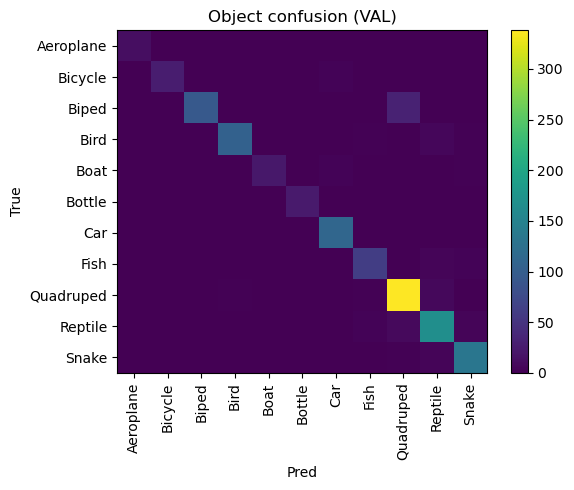

In [15]:
# ===== Cell 6: final object classification on VAL =====
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

vl_loss, vl_acc = _eval_split(Xvl_emb, Xvl_scr, Yvl, fusion)
print(f"[fusion] FINAL VAL object accuracy = {vl_acc:.3f} (loss={vl_loss:.4f})")

# quick confusion (no seaborn; one chart)
with torch.no_grad():
    logits = []
    for sl in _batches(Yvl.shape[0], bs=128):
        logits.append(fusion(Xvl_emb[sl].to(DEVICE), Xvl_scr[sl].to(DEVICE)).cpu())
    logits = torch.cat(logits, 0)
    y_true = Yvl.numpy()
    y_pred = logits.argmax(1).numpy()

cm = np.zeros((num_objects, num_objects), dtype=np.int64)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

plt.figure(figsize=(6, 5))
plt.imshow(cm, aspect='auto', interpolation='nearest')
plt.colorbar()
plt.xticks(range(num_objects), OBJECT_CLASSES, rotation=90)
plt.yticks(range(num_objects), OBJECT_CLASSES)
plt.xlabel("Pred")
plt.ylabel("True")
plt.title("Object confusion (VAL)")
plt.tight_layout()
plt.show()
